# Gemma-Scope Toxicity — SAE Firing-Structure & Count-Matched Classification (Demo)

This notebook is a **minimal, runnable demo** of the experiment
*"Gemma-Scope toxicity: SAE firing-structure, count-matched C1, selection ordering"* — the
**Two-Track Counterfactual Co-Response Grouping (CCRG)** method.

**The original `method.py` is a single-GPU experiment.** It encodes ~37k toxicity texts
(ParaDetox + civil_comments) through `gemma-2-2b` + a frozen Gemma-Scope SAE
(`gemma-scope-2b-pt-res-canonical`, `layer_12/width_16k`), groups the SAE latents into
cluster-level **units** (Leiden over co-response correlations + a K-track absorber search), and
benchmarks those units against raw-latent and non-SAE baselines. That GPU stage (model download,
activation capture, feature scoring) is **pre-computed** and shipped as per-example test-fold
predictions inside the data file.

**What this demo reproduces (CPU, well under a minute):** the *downstream* **C1 count-matched
classification analysis** — the decisive, benchmarked comparison — directly from those stored
predictions, using the experiment's **original statistics helpers, copied verbatim**
(`auc_1d`, `f1_score_simple`, `mcnemar_p`, `paired_bootstrap`, `holm_adjust`):

1. per-method **F1 / accuracy** on the toxicity target;
2. the two-track **unit** vs. each baseline — best raw latent `a`, co-activation `b`,
   decoder-geometry `c`, attribution direction `h`, diff-of-means `d`, full-residual probe `e` —
   via **exact McNemar + paired bootstrap + Holm-Bonferroni**;
3. the **collapse on the label-disjoint sub-attributes** (threat / identity_attack);

and contextualises them against the **full-run reference numbers** and the **K-necessity
firing-structure verdict** carried in the data file.

> **Honest headline (reproduced below).** The raw-latent SAE *unit* ties the simplest SAE
> baselines but is **beaten by attribution selection and a plain residual probe**, and
> **collapses** on the disjoint sub-attributes — exactly the benchmark pattern where simple
> baselines outperform raw-latent SAE grouping. On toxicity the SAE *firing* structure also
> departs from the *label* co-occurrence structure, so the K-necessity verdict is **REFUTED**.

In [1]:
# --- Dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Every package this demo needs (numpy, scipy, statsmodels, matplotlib) is pre-installed on Colab.
# On Colab: do NOT reinstall them (it corrupts the pre-loaded C extensions).
# Locally: install them at Colab's exact versions so the environment matches Colab.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')
print('dependencies ready')

dependencies ready



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (subset of method.py's import block needed for the downstream analysis) ---
import json, math
import numpy as np
from scipy.stats import rankdata          # used by the tie-aware AUC helper, verbatim from method.py
import matplotlib.pyplot as plt           # demo-only: final visualisation

# numpy 2.0 compatibility shims (harmless if already present)
if not hasattr(np, 'alltrue'): np.alltrue = np.all
if not hasattr(np, 'product'): np.product = np.prod

print('numpy', np.__version__)

numpy 2.0.2


In [3]:
# --- Data loading: GitHub URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-2/experiment-2/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print('description:', data['description'][:120], '...')
print('n examples :', len(data['examples']))
print('methods    :', list(data['method_names'].keys()))
print('sub-attrs  :', data['sub_order'])

description: Curated 100-example subset of art_-o2RPMOZp37A test-fold predictions (civil_comments). Each example has the ground-truth ...
n examples : 100
methods    : ['unit', 'a', 'b', 'c', 'h', 'd', 'e']
sub-attrs  : ['severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit']


## Config

All tunable parameters live here. The heavy GPU stage is pre-computed, so the only real knob is
the **bootstrap resample count** `B_BOOT`. Values start small for a fast first run and are scaled
up toward the original settings (commented inline).

In [5]:
# ============================ DEMO CONFIG ============================
B_BOOT        = 10000     # paired-bootstrap resamples for the unit-vs-method gap CIs
                          #   matches method.py's toxicity headline b_boot=10000 (b_boot_aux=2000 for subs).
                          #   For a faster first pass, drop to e.g. 500 — the comparison pattern is unchanged.
N_EXAMPLES    = 100       # curated test-fold examples to analyse (mini set holds 100)
SEED          = 0         # CONFIG['seed'] in method.py

# methods compared in C1 (predictions shipped for these 7); 'unit' is the proposed two-track unit
METHODS       = ['unit', 'a', 'b', 'c', 'h', 'd', 'e']
BASELINES     = ['a', 'b', 'c', 'h', 'd', 'e']        # each compared against 'unit'
DISJOINT_SUBS = ['threat', 'identity_attack']         # CONFIG['disjoint_subs']
NAMES         = data['method_names']
print('B_BOOT =', B_BOOT, '| N_EXAMPLES =', N_EXAMPLES)

B_BOOT = 10000 | N_EXAMPLES = 100


## Statistics helpers (verbatim from `method.py`)

These are copied **unchanged** from the original `STATISTICS HELPERS` block of `method.py`:
tie-aware AUC, simple F1, exact McNemar, the paired bootstrap, bootstrap CIs, and Holm
multiple-comparison adjustment. The demo feeds them the **stored predictions** instead of
GPU-computed scores; the analysis code itself is the original.

In [6]:
from scipy.stats import rankdata


def auc_1d(scores, y):
    """Tie-aware AUC (Mann-Whitney) for a 1-D score vector."""
    y = np.asarray(y).astype(bool)
    npos = int(y.sum()); nneg = int((~y).sum())
    if npos == 0 or nneg == 0:
        return float("nan")
    r = rankdata(scores)
    return float((r[y].sum() - npos * (npos + 1) / 2.0) / (npos * nneg))


def f1_score_simple(pred, y):
    pred = np.asarray(pred).astype(bool); y = np.asarray(y).astype(bool)
    tp = int((pred & y).sum()); fp = int((pred & ~y).sum()); fn = int((~pred & y).sum())
    return 2 * tp / max(2 * tp + fp + fn, 1)


def paired_bootstrap(score_u, score_m, pred_u, pred_m, y, B, rng):
    """Paired bootstrap over examples for AUC-diff and F1-diff (unit minus method)."""
    n = len(y)
    idx = rng.integers(0, n, size=(B, n), dtype=np.int64)
    pu = np.asarray(pred_u).astype(bool); pm = np.asarray(pred_m).astype(bool); yy = np.asarray(y).astype(bool)
    # F1 vectorized
    def f1_boot(pred):
        p = pred[idx]; yb = yy[idx]
        tp = (p & yb).sum(1).astype(np.float64)
        fp = (p & ~yb).sum(1).astype(np.float64)
        fn = (~p & yb).sum(1).astype(np.float64)
        return 2 * tp / np.maximum(2 * tp + fp + fn, 1)
    f1d = f1_boot(pu) - f1_boot(pm)
    # AUC loop (tie-aware), reusing the same resamples
    su = np.asarray(score_u, dtype=np.float64); sm = np.asarray(score_m, dtype=np.float64)
    aucd = np.empty(B)
    for b in range(B):
        ii = idx[b]; yb = yy[ii]
        aucd[b] = auc_1d(su[ii], yb) - auc_1d(sm[ii], yb)
    return dict(
        auc_diff_ci=[float(np.nanpercentile(aucd, 2.5)), float(np.nanpercentile(aucd, 97.5))],
        f1_diff_ci=[float(np.percentile(f1d, 2.5)), float(np.percentile(f1d, 97.5))],
        auc_diff_mean=float(np.nanmean(aucd)), f1_diff_mean=float(np.mean(f1d)),
    )


def mcnemar_p(pred_u, pred_m, y):
    from statsmodels.stats.contingency_tables import mcnemar
    cu = (np.asarray(pred_u).astype(bool) == np.asarray(y).astype(bool))
    cm = (np.asarray(pred_m).astype(bool) == np.asarray(y).astype(bool))
    b = int((cu & ~cm).sum()); c = int((~cu & cm).sum())
    a = int((cu & cm).sum()); d = int((~cu & ~cm).sum())
    table = [[a, b], [c, d]]
    try:
        res = mcnemar(table, exact=True)
        return float(res.pvalue), table
    except Exception:
        return float("nan"), table


def holm_adjust(pdict):
    from statsmodels.stats.multitest import multipletests
    keys = [k for k, v in pdict.items() if v is not None and not (isinstance(v, float) and math.isnan(v))]
    if not keys:
        return {}
    pv = [pdict[k] for k in keys]
    rej, padj, _, _ = multipletests(pv, method="holm")
    return {k: float(p) for k, p in zip(keys, padj)}


def boot_ci(vals, lo=2.5, hi=97.5):
    vals = np.asarray(vals, dtype=np.float64)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return [float("nan"), float("nan")]
    return [float(np.percentile(vals, lo)), float(np.percentile(vals, hi))]

print('helpers loaded:', [f.__name__ for f in (auc_1d, f1_score_simple, paired_bootstrap, mcnemar_p, holm_adjust, boot_ci)])

helpers loaded: ['auc_1d', 'f1_score_simple', 'paired_bootstrap', 'mcnemar_p', 'holm_adjust', 'boot_ci']


## Parse the stored predictions

Each example carries the ground-truth toxicity label, the sub-attribute labels, and the **binary
prediction of every method** (`predict_unit`, `predict_a`, …). We turn the `"toxic"/"non_toxic"`
strings into 0/1 arrays — these binary predictions stand in for the GPU-computed `preds_te` that
`method.py` produced in stage 5.

In [7]:
examples = data['examples'][:N_EXAMPLES]

# ground-truth toxicity label
y = np.array([int(e['metadata_toxicity_label']) for e in examples], dtype=np.int8)

# per-method binary predictions ("toxic" -> 1, "non_toxic" -> 0)
to_bin = lambda v: 1 if v == 'toxic' else 0
pred = {m: np.array([to_bin(e[f'predict_{m}']) for e in examples], dtype=np.int8) for m in METHODS}

# sub-attribute labels (for the disjoint-sub collapse check)
sub = {s: np.array([int(e.get(f'metadata_sub_{s}', 0)) for e in examples], dtype=np.int8)
       for s in data['sub_order']}

print(f'examples = {len(examples)}   toxic = {int(y.sum())}   clean = {int((1 - y).sum())}')
for s in DISJOINT_SUBS:
    print(f'  sub[{s}] positives = {int(sub[s].sum())}')

examples = 100   toxic = 50   clean = 50
  sub[threat] positives = 3
  sub[identity_attack] positives = 3


## C1 — per-method scores on the toxicity target

Per-method **F1**, **accuracy**, and **balanced accuracy** on the demo subset. (For a *binary*
predictor, the tie-aware `auc_1d` reduces to balanced accuracy — `(TPR+TNR)/2`.) The full-run
*continuous-score* AUCs are shown alongside, straight from the data file's reference block.

In [8]:
accuracy = lambda p, yy: float((np.asarray(p) == np.asarray(yy)).mean())
ref_pm = data['reference_c1_full_run']['toxicity']['per_method']

rows = []
for m in METHODS:
    rows.append(dict(
        method=m,
        demo_f1=f1_score_simple(pred[m], y),
        demo_acc=accuracy(pred[m], y),
        demo_balacc=auc_1d(pred[m].astype(float), y),
        ref_auc_fullrun=ref_pm.get(m, {}).get('auc'),
        ref_f1_fullrun=ref_pm.get(m, {}).get('f1'),
    ))

print(f"{'method':<6}{'name':<34}{'demo_F1':>9}{'demo_acc':>9}{'demo_balAcc':>12}{'ref_AUC(full)':>15}")
print('-' * 85)
for r in sorted(rows, key=lambda x: -x['demo_f1']):
    nm = NAMES[r['method']][:32]
    ra = f"{r['ref_auc_fullrun']:.3f}" if r['ref_auc_fullrun'] is not None else '   -'
    star = '  <- two-track unit' if r['method'] == 'unit' else ''
    print(f"{r['method']:<6}{nm:<34}{r['demo_f1']:>9.3f}{r['demo_acc']:>9.3f}"
          f"{r['demo_balacc']:>12.3f}{ra:>15}{star}")

methodname                                demo_F1 demo_acc demo_balAcc  ref_AUC(full)
-------------------------------------------------------------------------------------
h     SCR/TPP raw-direction (attributi      0.708    0.720       0.720          0.837
e     logistic regression on full resi      0.674    0.720       0.720          0.859
a     best single raw SAE latent            0.667    0.500       0.500          0.765
b     co-activation neighbours              0.667    0.500       0.500          0.797
c     decoder-geometry neighbours           0.667    0.500       0.500          0.792
unit  two-track co-response unit (k=3)      0.624    0.530       0.530          0.762  <- two-track unit
d     non-SAE diff-of-means probe           0.477    0.540       0.540          0.778


## C1 — the two-track unit vs. each baseline

The core comparison: `unit` against every other method via **exact McNemar** (`mcnemar_p`) and the
**paired bootstrap** (`paired_bootstrap`, F1-diff & balanced-accuracy-diff CIs), with
**Holm-Bonferroni** across the family of comparisons — all original `method.py` code. A negative
diff means the unit is *worse* than that baseline.

In [9]:
rng = np.random.default_rng(SEED)
pu = pred['unit']

comps, pdict = {}, {}
for m in BASELINES:
    bs = paired_bootstrap(pu.astype(float), pred[m].astype(float), pu, pred[m], y, B_BOOT, rng)
    p, table = mcnemar_p(pu, pred[m], y)
    comps[m] = dict(**bs, mcnemar_p=p, table=table)
    pdict[m] = p

padj = holm_adjust(pdict)
for m in BASELINES:
    comps[m]['mcnemar_p_holm'] = padj.get(m)

print(f"unit vs   {'name':<34}{'F1diff':>8}{'F1diff_CI':>20}{'McNemar_p':>12}{'Holm_p':>12}")
print('-' * 100)
for m in BASELINES:
    c = comps[m]; lo, hi = c['f1_diff_ci']
    print(f"unit-{m:<5}{NAMES[m][:32]:<34}{c['f1_diff_mean']:>8.3f}"
          f"   [{lo:+.3f},{hi:+.3f}]{c['mcnemar_p']:>12.2e}{c['mcnemar_p_holm']:>12.2e}")

print('\nReference (full run, n=2980): unit-h F1diff CI [-0.120,-0.088], McNemar p ~ 5e-71'
      '  =>  unit significantly WORSE than attribution (h) and residual probe (e).')

unit vs   name                                F1diff           F1diff_CI   McNemar_p      Holm_p
----------------------------------------------------------------------------------------------------
unit-a    best single raw SAE latent          -0.043   [-0.118,+0.028]    6.90e-01    1.00e+00
unit-b    co-activation neighbours            -0.043   [-0.118,+0.028]    6.90e-01    1.00e+00
unit-c    decoder-geometry neighbours         -0.043   [-0.118,+0.030]    6.90e-01    1.00e+00
unit-h    SCR/TPP raw-direction (attributi    -0.084   [-0.203,+0.035]    9.40e-03    5.64e-02
unit-d    non-SAE diff-of-means probe          0.147   [-0.009,+0.298]    1.00e+00    1.00e+00
unit-e    logistic regression on full resi    -0.050   [-0.207,+0.102]    1.83e-02    9.17e-02

Reference (full run, n=2980): unit-h F1diff CI [-0.120,-0.088], McNemar p ~ 5e-71  =>  unit significantly WORSE than attribution (h) and residual probe (e).


## C1 — collapse on the label-disjoint sub-attributes

On the disjoint sub-attributes (`threat`, `identity_attack`) the raw-latent unit collapses while
attribution (`h`) holds up. Each sub uses its positives vs. the clean negatives (the `method.py`
stage-5 eligibility rule). The demo subset has only a few positives per sub, so the **full-run
reference** numbers are printed underneath — that is where the collapse is decisive.

In [10]:
ref_c1 = data['reference_c1_full_run']
for s in DISJOINT_SUBS:
    pos = sub[s] == 1; neg = y == 0; mask = pos | neg
    yt = pos[mask].astype(int)
    print(f"[{s}]  demo n_pos={int(pos.sum())}  (per-method F1 on demo subset)")
    for m in METHODS:
        print(f"      {m:<5}{NAMES[m][:30]:<32} F1={f1_score_simple(pred[m][mask], yt):.3f}")
    rb = ref_c1.get(s, {}).get('per_method', {})
    if rb:
        u = rb.get('unit', {}).get('auc'); h = rb.get('h', {}).get('auc')
        print(f"      full-run reference AUC: unit={u:.3f}  vs  h(attribution)={h:.3f}  "
              f"=>  unit COLLAPSES, attribution holds")
    print()

[threat]  demo n_pos=3  (per-method F1 on demo subset)
      unit two-track co-response unit (k=   F1=0.098
      a    best single raw SAE latent       F1=0.107
      b    co-activation neighbours         F1=0.107
      c    decoder-geometry neighbours      F1=0.107
      h    SCR/TPP raw-direction (attribu   F1=0.235
      d    non-SAE diff-of-means probe      F1=0.182
      e    logistic regression on full re   F1=0.462
      full-run reference AUC: unit=0.626  vs  h(attribution)=0.929  =>  unit COLLAPSES, attribution holds

[identity_attack]  demo n_pos=3  (per-method F1 on demo subset)
      unit two-track co-response unit (k=   F1=0.098
      a    best single raw SAE latent       F1=0.107
      b    co-activation neighbours         F1=0.107
      c    decoder-geometry neighbours      F1=0.107
      h    SCR/TPP raw-direction (attribu   F1=0.125
      d    non-SAE diff-of-means probe      F1=0.000
      e    logistic regression on full re   F1=0.462
      full-run reference AUC: un

## Firing-structure verdict (carried in the data file)

The cheap, decisive MAJOR-2 finding from the full run: a single **general toxicity latent** `g`
fires on the vast majority of toxic content-flips, the per-sub detector latents *co-fire* with it
(firing-Jaccard far above the 0.10 absorption threshold), so the SAE firing structure **departs
from** the label co-occurrence structure and the **K-necessity verdict is REFUTED**.

In [11]:
fs = data['reference_firing_structure']
print('general toxicity latent g     :', fs['general_latent_idx'])
print('g recall on toxic content     : {:.3f}'.format(fs['general_recall_toxic']))
print('K-necessity verdict           :', fs['k_necessity_verdict'])
print('\nper-sub detector latents (best single-latent AUC vs clean negatives):')
for s, idx in fs['detector_idx_per_sub'].items():
    auc = fs['detector_auc_per_sub'].get(s)
    print(f'   {s:<18} latent={idx:<7} AUC={auc:.3f}' if auc is not None else f'   {s:<18} latent={idx}')

general toxicity latent g     : 12714
g recall on toxic content     : 0.656
K-necessity verdict           : REFUTED

per-sub detector latents (best single-latent AUC vs clean negatives):
   obscene            latent=12714   AUC=0.977
   threat             latent=11630   AUC=0.828
   insult             latent=13367   AUC=0.871
   identity_attack    latent=11573   AUC=0.930
   sexual_explicit    latent=12714   AUC=0.888


## Visualization

Left: demo-computed per-method **F1** on the toxicity target (the unit highlighted). Right: the
**full-run reference AUC** for the same methods. Both tell the same story — the raw-latent SAE unit
sits with the simplest baselines and is **beaten by attribution (`h`), the SCR/TPP pool (`g`), and
the plain residual probe (`e`)**.

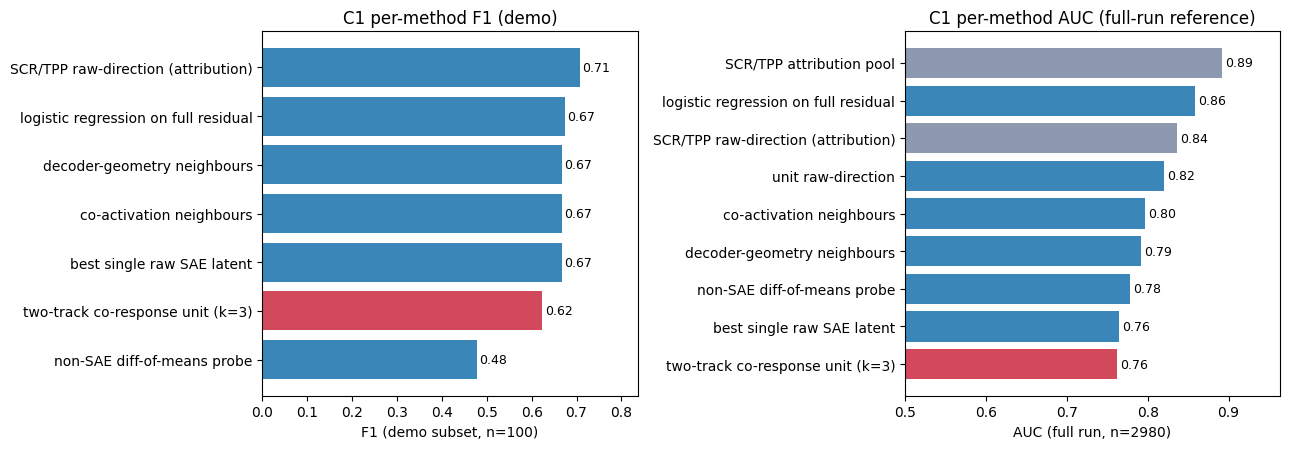


Verdict reproduced: raw-latent SAE "unit" ties simple baselines but is beaten by attribution / residual probe; K-necessity = REFUTED.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- left: demo F1 ---
order = sorted(METHODS, key=lambda m: f1_score_simple(pred[m], y))
vals = [f1_score_simple(pred[m], y) for m in order]
colors = ['#d1495b' if m == 'unit' else '#3a86b8' for m in order]
ax1.barh([NAMES[m] for m in order], vals, color=colors)
for i, v in enumerate(vals):
    ax1.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
ax1.set_xlabel('F1 (demo subset, n=%d)' % len(examples))
ax1.set_title('C1 per-method F1 (demo)')
ax1.set_xlim(0, max(vals) * 1.18)

# --- right: full-run reference AUC ---
ref_pm = data['reference_c1_full_run']['toxicity']['per_method']
ref_methods = [m for m in ['a', 'b', 'c', 'unit', 'd', 'unit_rawdir', 'h', 'e', 'g'] if m in ref_pm]
ref_methods = sorted(ref_methods, key=lambda m: ref_pm[m]['auc'])
rauc = [ref_pm[m]['auc'] for m in ref_methods]
rcolors = ['#d1495b' if m == 'unit' else ('#8d99ae' if m in ('g', 'h') else '#3a86b8') for m in ref_methods]
labels = [NAMES.get(m, {'g': 'SCR/TPP attribution pool', 'unit_rawdir': 'unit raw-direction'}.get(m, m)) for m in ref_methods]
ax2.barh(labels, rauc, color=rcolors)
for i, v in enumerate(rauc):
    ax2.text(v + 0.004, i, f'{v:.2f}', va='center', fontsize=9)
ax2.axvline(0.5, color='k', ls=':', lw=0.8)
ax2.set_xlabel('AUC (full run, n=2980)')
ax2.set_title('C1 per-method AUC (full-run reference)')
ax2.set_xlim(0.5, max(rauc) * 1.08)

plt.tight_layout()
plt.show()

print('\nVerdict reproduced: raw-latent SAE "unit" ties simple baselines but is beaten by'
      ' attribution / residual probe; K-necessity = %s.' % data['reference_firing_structure']['k_necessity_verdict'])